# LCA model 

- Collect user inputs 
- Calculate environmental impact with LCA 
- Display results 

## User inputs 

### Bill of materials

Composition given as percentages of the input mass at each stage — production and repair each have their own BOM, since repair material can have a different mix. `allocation_type` drives whether a material's own burden or the shared transport burden gets used later.

In [156]:
from dataclasses import dataclass
from typing import Optional, List

@dataclass
class BOMItem:
    material_name: str
    percentage: float       # share of total input mass at this stage — all items in one BOM should sum to 100
    material_source: str    # "virgin" / "co-product" / "recycled" / "wild-harvested"

def check_bom(bom: List[BOMItem], label: str, tol: float = 0.01):
    total = sum(item.percentage for item in bom)
    if abs(total - 100) > tol:
        raise ValueError(f"{label} BOM percentages sum to {total}, not 100")
    print(f"{label} BOM: {len(bom)} materials, {total:.1f}%")


# ── Production BOM — 3D-printed biopolymer panel ──────────────────────────────
production_bom = [
    BOMItem("Pea protein binder", 70, "virgin"),
    BOMItem("Sawdust",            20, "co-product"),
    BOMItem("Seagrass",           10, "wild-harvested"),
]
check_bom(production_bom, "Production")

# ── Repair BOM — different mix, replaces part of the product ──────────────────
repair_bom = [
    BOMItem("Pea protein binder", 80, "virgin"),
    BOMItem("Seagrass",           10, "wild-harvested"),
    BOMItem("Hemp fiber",         10, "virgin"),
]
check_bom(repair_bom, "Repair")

Production BOM: 3 materials, 100.0%
Repair BOM: 3 materials, 100.0%


### Production process chain 

ordered steps, each with its own machine/energy parameters and electricity location; `retained_pct` is the share of mass carried into the next step — only the last step in a chain omits it, since it produces the target output directly

In [157]:
@dataclass
class ProcessStep:
    step_name: str
    kg_machine: float
    power_kW: float
    rate_kg_per_hr: float
    machine_lifetime_hrs: float
    electricity_location: str
    retained_pct: float          # % of mass retained after this step, including the last one
    machine_source: str = "virgin"  # "virgin" or "recycled" — which machine-wear burden to use

# ── Production chain — mixing → 3D printing → baking ──────────────────────────
# ── Production chain — mixing → 3D printing → baking ──────────────────────────
production_chain = [
    ProcessStep("Mixing",     kg_machine=80,  power_kW=1.5, rate_kg_per_hr=15.0,
                machine_lifetime_hrs=15000, electricity_location="NL", retained_pct=98),
    ProcessStep("3D printing", kg_machine=250, power_kW=2.5, rate_kg_per_hr=0.5,
                machine_lifetime_hrs=20000, electricity_location="NL", retained_pct=92,
                machine_source="recycled"),  # example: this machine is recycled
    ProcessStep("Baking",     kg_machine=500, power_kW=8.0, rate_kg_per_hr=4.0,
                machine_lifetime_hrs=25000, electricity_location="NL", retained_pct=30),
]

product_kg = 1.0
print(f"Production chain: {len(production_chain)} steps → target output {product_kg} kg")

Production chain: 3 steps → target output 1.0 kg


### Repair

repairs use their own (shorter) chain — no baking, since repairs dry on-site — and their own BOM; `repair_material_kg` is the mass added per repair event, expressed as a share of the product mass

In [158]:
# ── Repair chain — mixing → 3D printing, no baking (dries on-site) ────────────
repair_chain = [
    ProcessStep("Mixing",      kg_machine=80,  power_kW=1.5, rate_kg_per_hr=15.0,
                machine_lifetime_hrs=15000, electricity_location="NL", retained_pct=98),
    ProcessStep("3D printing", kg_machine=250, power_kW=2.5, rate_kg_per_hr=0.5,
                machine_lifetime_hrs=20000, electricity_location="NL", retained_pct=92),
]

repair_material_kg = 0.10 * product_kg  # each repair event replaces 10% of the product

expected_lifetime_yr = 20
lifetime_extension_per_repair_yr = 10
number_of_repair_events = 3

print(f"Repair chain: {len(repair_chain)} steps → {repair_material_kg} kg per event")
print(f"Lifetime: {expected_lifetime_yr} yr, +{lifetime_extension_per_repair_yr} yr × {number_of_repair_events} repairs "
      f"= {expected_lifetime_yr + lifetime_extension_per_repair_yr * number_of_repair_events} yr total")

Repair chain: 2 steps → 0.1 kg per event
Lifetime: 20 yr, +10 yr × 3 repairs = 50 yr total


### End of life

In [159]:
# ── End-of-life user inputs ────────────────────────────────────────────────
# share_recycled_closed is NOT set here — it's derived below from the BOM's
# recycled-content share, since closed-loop recycling assumes the same fraction
# of material that entered as recycled content exits the same way (§ your Part A note).
share_composted      = 30   # %
share_recycled_open  = 20   # %
share_recycled_closed = 30   # %
share_incinerated     = 10  # %
share_landfilled      = 10  # %

disposal_electricity_location = "NL"  # grid location for avoided incineration-electricity credit

eol_shares = {
    "composted": share_composted,
    "recycled (open loop)": share_recycled_open,
    "recycled (closed loop)": share_recycled_closed,
    "incinerated": share_incinerated,
    "landfilled": share_landfilled,
}
total_share = sum(eol_shares.values())
if abs(total_share - 100) > 0.01:
    raise ValueError(f"EoL disposal shares sum to {total_share:.1f}%, not 100% — got {eol_shares}")

In [160]:
total_disposed_kg = product_kg + repair_material_kg * number_of_repair_events

def get_recycled_share(bom):
    """Fraction (0-1) of a BOM's mass sourced from closed-loop recycled content."""
    return sum(item.percentage for item in bom if item.material_source == "recycled") / 100

production_recycled_share = get_recycled_share(production_bom)
repair_recycled_share = get_recycled_share(repair_bom)

print(f"Total disposed mass: {total_disposed_kg:.3f} kg "
      f"(product {product_kg} kg + {number_of_repair_events} repair events × {repair_material_kg:.3f} kg)")
print("Disposal split: " + ", ".join(f"{k}={v:.1f}%" for k, v in eol_shares.items()))

Total disposed mass: 1.300 kg (product 1.0 kg + 3 repair events × 0.100 kg)
Disposal split: composted=30.0%, recycled (open loop)=20.0%, recycled (closed loop)=30.0%, incinerated=10.0%, landfilled=10.0%


## LCA calculation 

Calculate environmental impact based on 
- user inputs
- pre-calculated environmental data, see `01_dataPrep.ipynb`

### Burdens

Burdens come from three sources: the materials that go into the product, the
production process that assembles it, and any repair events over its lifetime.

#### Load pre-calculated unit data 

Loads `unit_burdens.csv` and sets up two helpers used by every burden calculation
below: `get_unit_burden()` looks up a single material/process's burden vector across
all EF v3.1 categories, and `get_material_unit_burden()` additionally applies the
allocation-type substitution — non-"product" materials borrow the shared
`Road transport` burden instead of their own row, same logic as `01_dataPrep.ipynb`.

In [161]:
import pandas as pd

OUTPUT_DIR = "../../data/processed"  # adjust to match your repo structure

df_burdens = pd.read_csv(f"{OUTPUT_DIR}/unit_burdens.csv")
CATEGORIES = df_burdens["impact_category"].unique().tolist()
TRANSPORT_MATERIAL_NAME = "Road transport"

def get_unit_burden(name, location=None, material_source=None):
    """Burden (all EF v3.1 categories) per unit of `name`, indexed by impact_category.
    Pass `location` for country-specific processes (e.g. energy use), and
    `material_source` when a process/material has more than one row per category
    (e.g. machine wear: virgin vs. recycled)."""
    rows = df_burdens[df_burdens["material_name"] == name]
    if location is not None:
        rows = rows[rows["location"] == location]
    if material_source is not None:
        rows = rows[rows["material_source"] == material_source]
    if rows.empty:
        raise ValueError(f"No burden data for '{name}'"
                          + (f" in location '{location}'" if location else "")
                          + (f" with source '{material_source}'" if material_source else ""))
    if rows["impact_category"].duplicated().any():
        raise ValueError(f"'{name}' still has duplicate impact_category rows after filtering — "
                          f"add another filter (location/material_source) to disambiguate.")
    return rows.set_index("impact_category")["score"]

def get_unit_burden_by_source(material_name, material_source):
    """Burden (all EF v3.1 categories) per unit of `material_name` sourced as `material_source`
    ('virgin' / 'co-product' / 'recycled' / 'wild-harvested'), indexed by impact_category."""
    rows = df_burdens[
        (df_burdens["material_name"] == material_name) &
        (df_burdens["material_source"] == material_source)
    ]
    if rows.empty:
        raise ValueError(f"No burden data for '{material_name}' sourced as '{material_source}'")
    return rows.set_index("impact_category")["score"]


def is_growth_eligible(material_source):
    """True if this material's carbon was sequestered by growth attributable to this
    product (virgin only). Co-product, recycled, and wild-harvested are all diverted/
    waste flows — avoided-emissions credit instead of a growth credit."""
    return material_source == "virgin"


def get_material_unit_burden(material_name, material_source):
    """
    Burden (all EF v3.1 categories) per unit of `material_name`, following the CFF
    acquisition formula:
      virgin / co-product / wild-harvested → direct unit burden for that source
      recycled                             → A * E_recycled + (1-A) * E_virgin * (Qs_in / Qp)
    """
    if material_source == "recycled":
        A, quality_ratio, _ = get_eol_constants(material_name)
        e_recycled = get_unit_burden_by_source(material_name, "recycled")
        e_virgin = get_unit_burden_by_source(material_name, "virgin")
        return A * e_recycled + (1 - A) * e_virgin * (quality_ratio / QUALITY_RATIO_PRIMARY)
    else:
        return get_unit_burden_by_source(material_name, material_source)

print(f"Loaded unit burdens: {df_burdens['material_name'].nunique()} materials/processes × {len(CATEGORIES)} categories")

Loaded unit burdens: 27 materials/processes × 25 categories


In [162]:
df_eol_constants = pd.read_csv(f"{OUTPUT_DIR}/eol_constants.csv").set_index("material_name")

def get_eol_constants(material_name):
    """(allocation_factor, quality_ratio, LHV_MJperKgDry) for a material — used by both
    the acquisition-side CFF formula (recycled materials, this section) and the
    end-of-life CFF formula (later section)."""
    if material_name not in df_eol_constants.index:
        raise ValueError(f"No EoL constants for '{material_name}'")
    row = df_eol_constants.loc[material_name]
    return row["allocation_factor"], row["quality_ratio"], row["lower_heating_value_MJperKgDry"]

QUALITY_RATIO_PRIMARY = 1.0  # Qp — quality of primary/virgin material; no source data yet, assumed 1.0

print(f"Loaded EoL/CFF constants for {len(df_eol_constants)} materials")

Loaded EoL/CFF constants for 12 materials


In [163]:
CONV_EFF_HEAT = 0.6   # fraction of LHV exported as usable heat (standard CHP figure)
CONV_EFF_ELEC = 0.25  # fraction of LHV exported as usable electricity (standard CHP figure)

A_eol, quality_ratio_eol, LHV = get_eol_constants("RAW product")

print(f"RAW product EoL constants: A={A_eol}, quality_ratio={quality_ratio_eol}, LHV={LHV} MJ/kg")

RAW product EoL constants: A=0.8, quality_ratio=0.9, LHV=16.4 MJ/kg


#### Material burdens

Burden of the raw materials feeding the production chain. Since the bill of
materials is percentage-based and the process chain is solved backward from a
target output (see `#### Production burdens` below), this depends on
`total_input_kg` — the actual mass required at the first production step — which
is why material burdens are computed *after* solving the chain, not before.

In [164]:
def compute_material_burdens(bom, total_input_kg):
    """Total burden (all categories) for a BOM, given the total input mass it represents.
    Uses the CFF acquisition formula (see get_material_unit_burden) per material_source."""
    total = pd.Series(0.0, index=CATEGORIES)
    for item in bom:
        kg = total_input_kg * item.percentage / 100
        unit_burden = get_material_unit_burden(item.material_name, item.material_source)
        total = total.add(unit_burden * kg, fill_value=0.0)
    return total

#### Production burdens

Solves the process chain backward from `product_kg` (same logic as the HTML tool):
the last step's required input equals the target output directly; each earlier
step's required input is back-calculated from the next step's requirement, divided
by its own `retained_pct`. Machine wear and energy use are then computed per step
from that required throughput, and converted to impacts via the machine-wear and
location-specific electricity unit burdens.

In [165]:
def compute_process_burdens(chain, target_output_kg):
    """
    Solves a process chain backward from `target_output_kg`, and returns:
      total    — combined burden (all categories) across every step
      df_steps — per-step required_input_kg / process_time_hrs / machine_wear_kg / energy_use_kwh
    """
    n = len(chain)
    required_input_kg = [None] * n
    next_required = target_output_kg

    for i in range(n - 1, -1, -1):
        step = chain[i]
        required_input_kg[i] = next_required / (step.retained_pct / 100)
        next_required = required_input_kg[i]

    total = pd.Series(0.0, index=CATEGORIES)
    step_rows = []

    for i, step in enumerate(chain):
        process_time_hrs = required_input_kg[i] / step.rate_kg_per_hr
        machine_wear_kg = step.kg_machine * (process_time_hrs / step.machine_lifetime_hrs)
        energy_use_kwh = step.power_kW * process_time_hrs

        machine_burden = get_unit_burden("machine wear", material_source=step.machine_source) * machine_wear_kg
        electricity_burden = get_unit_burden("energy use", location=step.electricity_location) * energy_use_kwh
                                
        total = total.add(machine_burden, fill_value=0.0).add(electricity_burden, fill_value=0.0)
        step_rows.append({
            "step_name": step.step_name, "required_input_kg": required_input_kg[i],
            "process_time_hrs": process_time_hrs,
            "machine_wear_kg": machine_wear_kg, "energy_use_kwh": energy_use_kwh,
        })

    return total, pd.DataFrame(step_rows)


production_process_burdens, df_production_steps = compute_process_burdens(production_chain, product_kg)
total_material_input_kg = df_production_steps["required_input_kg"].iloc[0]

material_burdens = compute_material_burdens(production_bom, total_material_input_kg)

print(f"Total raw material input required: {total_material_input_kg:.3f} kg (for {product_kg} kg product)")
df_production_steps

Total raw material input required: 3.697 kg (for 1.0 kg product)


,step_name,required_input_kg,process_time_hrs,machine_wear_kg,energy_use_kwh
0,Mixing,3.697131,0.246475,0.001315,0.369713
1,3D printing,3.623188,7.246377,0.090580,18.115942
2,Baking,3.333333,0.833333,0.016667,6.666667


#### Repair burdens 

Same chain-solving and material-burden logic as production, applied to the repair
BOM and repair chain, then scaled by `number_of_repair_events` — since each event
consumes the same repair material and process burden.

In [166]:
repair_process_burdens_per_event, df_repair_steps = compute_process_burdens(repair_chain, repair_material_kg)
repair_material_input_kg = df_repair_steps["required_input_kg"].iloc[0]

repair_material_burdens_per_event = compute_material_burdens(repair_bom, repair_material_input_kg)

repair_burdens = (
    (repair_process_burdens_per_event + repair_material_burdens_per_event) * number_of_repair_events
)

print(f"Repair material input per event: {repair_material_input_kg:.3f} kg (for {repair_material_kg} kg replaced)")
print(f"Total across {number_of_repair_events} repair events")
df_repair_steps

Repair material input per event: 0.111 kg (for 0.1 kg replaced)
Total across 3 repair events


,step_name,required_input_kg,process_time_hrs,machine_wear_kg,energy_use_kwh
0,Mixing,0.110914,0.007394,0.000039,0.011091
1,3D printing,0.108696,0.217391,0.002717,0.543478


#### End of life burdens

In [167]:
compost_burden        = abs((1 - A_eol) * (share_composted / 100)      * get_unit_burden("waste composting")   * total_disposed_kg)
recycle_open_burden   = abs((1 - A_eol) * (share_recycled_open / 100)  * get_unit_burden("waste recycling")    * total_disposed_kg)
recycle_closed_burden = abs((1 - A_eol) * (share_recycled_closed / 100)* get_unit_burden("waste recycling")    * total_disposed_kg)
incinerate_burden     = abs((share_incinerated / 100)    * get_unit_burden("waste incineration") * total_disposed_kg)
landfill_burden        = abs((share_landfilled / 100)     * get_unit_burden("waste landfilling")  * total_disposed_kg)

eol_burdens = (
    compost_burden.add(recycle_open_burden, fill_value=0.0)
    .add(recycle_closed_burden, fill_value=0.0)
    .add(incinerate_burden, fill_value=0.0)
    .add(landfill_burden, fill_value=0.0)
)

print("EoL burdens by route (climate change category, kg CO2-eq):")
print(f"  Compost:          {compost_burden['climate change']:.4f}")
print(f"  Recycle (open):   {recycle_open_burden['climate change']:.4f}")
print(f"  Recycle (closed): {recycle_closed_burden['climate change']:.4f}")
print(f"  Incinerate:       {incinerate_burden['climate change']:.4f}")
print(f"  Landfill:         {landfill_burden['climate change']:.4f}")
print(f"  TOTAL EoL burden: {eol_burdens['climate change']:.4f}")

EoL burdens by route (climate change category, kg CO2-eq):
  Compost:          0.0048
  Recycle (open):   0.0026
  Recycle (closed): 0.0038
  Incinerate:       0.0052
  Landfill:         0.0686
  TOTAL EoL burden: 0.0850


#### Total burdens

Sum of material, production, and repair burdens — the full-lifecycle burden side of
the result, before any carbon sequestration credit is applied.

In [168]:
total_burdens = material_burdens.add(production_process_burdens, fill_value=0.0).add(repair_burdens, fill_value=0.0)

print("Total burdens by source (climate change category, kg CO2-eq):")
print(f"  Material:   {material_burdens['climate change']:.4f}")
print(f"  Production: {production_process_burdens['climate change']:.4f}")
print(f"  Repair:     {repair_burdens['climate change']:.4f}")
print(f"  TOTAL:      {total_burdens['climate change']:.4f}")

Total burdens by source (climate change category, kg CO2-eq):
  Material:   1.4554
  Production: 8.9899
  Repair:     0.7869
  TOTAL:      11.2322


### Benefits (carbon sequestration)

Two mechanisms, both operating on the same `carbon_content_kgC_per_kg` data —
which one applies to a given material is determined by its `allocation_type`,
already set per BOM item:

- `allocation_type == "product"` → carbon sequestration from plant growth
  (GWP_bio, Guest et al. 2012) — this system is responsible for the material's
  cultivation, so it gets credit for the growth itself.
- `allocation_type in ("waste", "wild-harvested")` → carbon sequestration from
  avoided emissions (dynamic CF, Levasseur et al. 2010) — this system isn't
  responsible for the material's growth, only for delaying a release that would
  have happened anyway.

This mirrors `eligibility_for_allocation()` from `01_materials_module.ipynb`
Section 5.3 — same rule, just reused here.

#### Load unit benefit params

`carbon_content_kgC_per_kg` and `rotation_period_yr` per material, from
`unit_benefit_params.csv`.

In [169]:
df_unit_benefit_params = pd.read_csv(f"{OUTPUT_DIR}/benefits_constants.csv") 
df_benefit_params = df_unit_benefit_params.set_index("material_name")

def get_benefit_params(material_name):
    """(carbon_content_kgC_per_kgWet, rotation_period_yr) for a material."""
    if material_name not in df_benefit_params.index:
        raise ValueError(f"No benefit params for '{material_name}'")
    row = df_benefit_params.loc[material_name]
    return row["carbon_content_kgC_per_kgWet"], row["rotation_period_yr"]

print(f"Loaded benefit params for {len(df_benefit_params)} materials")
df_benefit_params[["carbon_content_kgC_per_kgWet", "rotation_period_yr"]]

Loaded benefit params for 10 materials


,carbon_content_kgC_per_kgWet,rotation_period_yr
material_name,,
Peas,0.407697,1.0
Cotton fiber,0.438425,1.0
Hemp fiber,0.445704,1.0
Bark chips,0.205833,80.0
Sawdust,0.290588,80.0
Hard wood,0.290588,100.0
Soft wood,0.290588,65.0
Cellulose reject fibers,0.404000,NaN
Seagrass,0.336000,NaN


#### Storage periods

Carbon sequestration credit depends on how long the carbon stays stored, which
differs for production material vs. each repair event:

- Production material — stored for the product's full lifespan, including all
  repair-driven extensions: `expected_lifetime_yr + lifetime_extension_per_repair_yr × number_of_repair_events`.
- Repair event *i*'s material — added partway through the product's life, so
  it's stored for less time. Assuming repairs happen sequentially, each exactly
  when the previous life stage would otherwise have ended, repair event *i*
  (1-indexed) is stored for `(number_of_repair_events − i + 1) × lifetime_extension_per_repair_yr`.

  For our example (3 repairs × 10 yr extension): repair 1 → 30 yr stored,
  repair 2 → 20 yr, repair 3 → 10 yr.

In [170]:
production_storage_yr = expected_lifetime_yr + lifetime_extension_per_repair_yr * number_of_repair_events

repair_storage_yr = [
    (number_of_repair_events - i + 1) * lifetime_extension_per_repair_yr
    for i in range(1, number_of_repair_events + 1)
]

print(f"Production material storage period: {production_storage_yr} yr")
print(f"Repair event storage periods:       {repair_storage_yr} yr  (event 1 → event {number_of_repair_events})")

Production material storage period: 50 yr
Repair event storage periods:       [30, 20, 10] yr  (event 1 → event 3)


#### GWP_bio and dynamic CF functions

Ported directly from `03_LifeCycleImpactAssessment_benefits.ipynb` — same
Guest et al. (2012) lookup table and Levasseur et al. (2010) Bern-model DCF.

In [171]:
import numpy as np

# ── GWP_bio lookup table — Guest et al. (2012), Table 1, 100-yr TH ────────────
ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
     1:   [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:   [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:   [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:   [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:   [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:   [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:   [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:   [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:   [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:   [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:   [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

def lookup_gwpbio(rotation_yr, storage_yr):
    """GWP_bio factor, linearly interpolated between 10-yr storage columns.
    rotation_yr is snapped to the nearest defined row if not an exact match."""
    nearest_rotation = min(GWPBIO_TABLE, key=lambda r: abs(r - rotation_yr))
    row = GWPBIO_TABLE[nearest_rotation]

    storage_yr = max(0, min(storage_yr, STORAGE_PERIODS[-1]))  # clip to table range
    if storage_yr % 10 == 0:
        return row[STORAGE_PERIODS.index(int(storage_yr))]

    lo = int(storage_yr // 10) * 10
    hi = lo + 10
    frac = (storage_yr - lo) / 10
    return row[STORAGE_PERIODS.index(lo)] * (1 - frac) + row[STORAGE_PERIODS.index(hi)] * frac


# ── Dynamic characterization factor (Levasseur et al., 2010) ─────────────────
# Bern carbon cycle model coefficients (Forster et al., 2007, via Levasseur et al. eq 3)
BERN_A = [0.217, 0.259, 0.338, 0.186]
BERN_TAU = [None, 172.9, 18.51, 1.186]  # tau_0 unused (a0 term has no decay)

def agwp_integral(t):
    """Integral of the Bern CO2 atmospheric load C(t') from 0 to t.
    Proportional to AGWP(t) — the radiative efficiency constant cancels
    out when DCF is computed as a ratio, so it's omitted here."""
    a0, a1, a2, a3 = BERN_A
    _, tau1, tau2, tau3 = BERN_TAU
    return (
        a0 * t
        + a1 * tau1 * (1 - np.exp(-t / tau1))
        + a2 * tau2 * (1 - np.exp(-t / tau2))
        + a3 * tau3 * (1 - np.exp(-t / tau3))
    )

def dynamic_cf(tau_storage, T=100):
    """Dynamic characterization factor for a CO2 pulse delayed by tau_storage
    years, evaluated over a fixed time horizon T (default 100 yr)."""
    return agwp_integral(T - tau_storage) / agwp_integral(T)


print(f"GWP_bio(rotation=1, storage=50):   {lookup_gwpbio(1, 50):.4f}")
print(f"Dynamic CF(storage=30, horizon=100): {dynamic_cf(30):.4f}")

GWP_bio(rotation=1, storage=50):   -0.4000
Dynamic CF(storage=30, horizon=100): 0.7619


#### Carbon sequestration from plant growth

For every BOM item (production + each repair event) with `allocation_type == "product"`:
`credit = carbon_content_kgC_per_kg × kg_material × 44/12 × GWP_bio(rotation_yr, storage_yr)`

In [172]:
MOLAR_RATIO = 44 / 12  # kg CO2 per kg C

def compute_sequestration_credit(bom, total_kg, storage_yr):
    """Sum of GWP_bio sequestration credit across a BOM's growth-eligible (virgin) items."""
    total = 0.0
    for item in bom:
        if not is_growth_eligible(item.material_source):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, rotation_yr = get_benefit_params(item.material_name)
        gwp = lookup_gwpbio(rotation_yr, storage_yr)
        total += carbon_content * kg * MOLAR_RATIO * gwp
    return total


production_sequestration = compute_sequestration_credit(
    production_bom, total_material_input_kg, production_storage_yr
)

repair_sequestration = sum(
    compute_sequestration_credit(repair_bom, repair_material_input_kg, storage_yr)
    for storage_yr in repair_storage_yr
)

sequestration_growth = production_sequestration + repair_sequestration

print(f"Production material sequestration credit: {production_sequestration:.4f} kg CO2-eq")
print(f"Repair material sequestration credit:      {repair_sequestration:.4f} kg CO2-eq")
print(f"Total (plant growth):                      {sequestration_growth:.4f} kg CO2-eq")

Production material sequestration credit: -1.0065 kg CO2-eq
Repair material sequestration credit:      -0.0470 kg CO2-eq
Total (plant growth):                      -1.0535 kg CO2-eq


#### Carbon sequestration from avoided emissions

For every BOM item with `allocation_type in ("waste", "wild-harvested")`:
`credit = carbon_content_kgC_per_kg × kg_material × 44/12 × (DCF(storage_yr, 100) − 1)`

In [173]:
def compute_delayed_emissions_credit(bom, total_kg, storage_yr):
    """Sum of dynamic-CF delayed-emissions credit across a BOM's non-growth-eligible
    (co-product / recycled / wild-harvested) items."""
    total = 0.0
    for item in bom:
        if is_growth_eligible(item.material_source):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, _ = get_benefit_params(item.material_name)
        dcf = dynamic_cf(storage_yr)
        total += carbon_content * kg * MOLAR_RATIO * (dcf - 1)
    return total


production_delayed_emissions = compute_delayed_emissions_credit(
    production_bom, total_material_input_kg, production_storage_yr
)

repair_delayed_emissions = sum(
    compute_delayed_emissions_credit(repair_bom, repair_material_input_kg, storage_yr)
    for storage_yr in repair_storage_yr
)

sequestration_avoided_emissions = production_delayed_emissions + repair_delayed_emissions

print(f"Production material delayed-emissions credit: {production_delayed_emissions:.4f} kg CO2-eq")
print(f"Repair material delayed-emissions credit:      {repair_delayed_emissions:.4f} kg CO2-eq")
print(f"Total (avoided emissions):                     {sequestration_avoided_emissions:.4f} kg CO2-eq")

Production material delayed-emissions credit: -0.5113 kg CO2-eq
Repair material delayed-emissions credit:      -0.0064 kg CO2-eq
Total (avoided emissions):                     -0.5177 kg CO2-eq


#### Total sequestration benefits

Sum of both credit mechanisms — climate change category only, same as the
reference notebook (neither mechanism has a defined credit in any other EF v3.1
category).

In [174]:
total_sequestration_benefits = pd.Series(0.0, index=CATEGORIES)
total_sequestration_benefits["climate change"] = sequestration_growth + sequestration_avoided_emissions

print("Total sequestration benefits by mechanism (climate change category, kg CO2-eq):")
print(f"  Plant growth (GWP_bio):        {sequestration_growth:.4f}")
print(f"  Avoided emissions (dynamic CF): {sequestration_avoided_emissions:.4f}")
print(f"  TOTAL:                          {total_sequestration_benefits['climate change']:.4f}")

Total sequestration benefits by mechanism (climate change category, kg CO2-eq):
  Plant growth (GWP_bio):        -1.0535
  Avoided emissions (dynamic CF): -0.5177
  TOTAL:                          -1.5712


#### Circularity benefits

In [175]:
compost_credit = (
    -(1 - A_eol) * (share_composted / 100)
    * get_unit_burden("avoided burden - composting") * quality_ratio_eol * total_disposed_kg
)
recycle_open_credit = (
    -(1 - A_eol) * (share_recycled_open / 100)
    * get_unit_burden("avoided buden - open loop recycling") * quality_ratio_eol * total_disposed_kg
)
incinerate_credit = (
    -(share_incinerated / 100) * LHV * total_disposed_kg
    * (CONV_EFF_HEAT * get_unit_burden("avoided burden - incineration, heat")
       + CONV_EFF_ELEC * get_unit_burden("avoided burden - incineration, electricity", location=disposal_electricity_location))
)

total_circularity_benefits = (
    compost_credit.add(recycle_open_credit, fill_value=0.0)
    .add(incinerate_credit, fill_value=0.0)
)

print("EoL benefits by route (climate change category, kg CO2-eq):")
print(f"  Compost credit:    {compost_credit['climate change']:.4f}")
print(f"  Recycle (open) credit: {recycle_open_credit['climate change']:.4f}")
print(f"  Incinerate credit: {incinerate_credit['climate change']:.4f}")
print(f"  TOTAL circularity benefit: {total_circularity_benefits['climate change']:.4f}")

EoL benefits by route (climate change category, kg CO2-eq):
  Compost credit:    -0.0003
  Recycle (open) credit: -0.0028
  Incinerate credit: -0.2588
  TOTAL circularity benefit: -0.2619


## Results 

### EU normalization factors 

EF v3.1 global per-capita normalisation factors (EC-JRC, 2010 baseline), same
category set as `EF_UNITS`. Sub-category flows (biogenic/fossil climate change,
organics/inorganics splits) share their parent category's factor, since EF only
defines normalisation at the 16 top-level category level.

In [176]:
EF_NORMALISATION = {
    'climate change':                                     8.10e+03,
    'climate change: biogenic':                           8.10e+03,
    'climate change: fossil':                              8.10e+03,
    'climate change: land use and land use change':        8.10e+03,
    'ecotoxicity: freshwater':                             4.27e+04,
    'ecotoxicity: freshwater, inorganics':                 4.27e+04,
    'ecotoxicity: freshwater, organics':                   4.27e+04,
    'energy resources: non-renewable':                     6.50e+04,
    'eutrophication: freshwater':                          1.61e+00,
    'eutrophication: marine':                              1.95e+01,
    'eutrophication: terrestrial':                         1.77e+02,
    'human toxicity: carcinogenic':                        1.72e-05,
    'human toxicity: carcinogenic, inorganics':            1.72e-05,
    'human toxicity: carcinogenic, organics':              1.72e-05,
    'human toxicity: non-carcinogenic':                    2.30e-04,
    'human toxicity: non-carcinogenic, inorganics':        2.30e-04,
    'human toxicity: non-carcinogenic, organics':          2.30e-04,
    'ionising radiation: human health':                    4.22e+03,
    'land use':                                            8.19e+05,
    'material resources: metals/minerals':                 6.36e-02,
    'ozone depletion':                                     5.36e-02,
    'particulate matter formation':                        5.95e-04,
    'photochemical oxidant formation: human health':       4.06e+01,
    'water use':                                           1.15e+04,
    'acidification':                                       5.56e+01,
}

missing_nf = [c for c in CATEGORIES if c not in EF_NORMALISATION]
if missing_nf:
    print(f"⚠ {len(missing_nf)} categories have no normalisation factor: {missing_nf}")
else:
    print(f"All {len(CATEGORIES)} categories have a normalisation factor.")

All 25 categories have a normalisation factor.


### GWP100 — burden, benefit, and net impact

Horizontal bar chart: total burden, total benefit, and their sum (net impact),
all in the `climate change` category (kg CO2-eq).

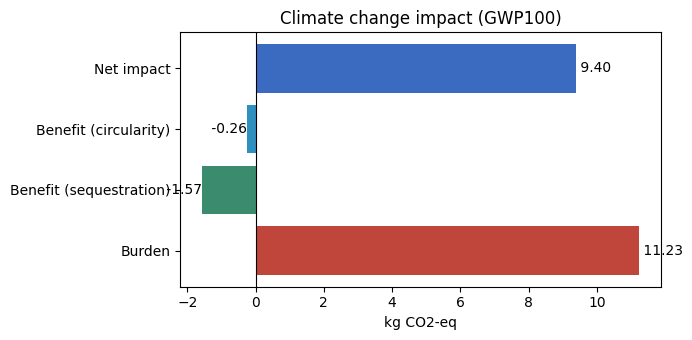

In [177]:
import matplotlib.pyplot as plt

gwp_burden = total_burdens["climate change"]
gwp_benefit_seq = total_sequestration_benefits["climate change"]
gwp_benefit_circ = total_circularity_benefits["climate change"]
gwp_net = gwp_burden + gwp_benefit_seq + gwp_benefit_circ

labels = ["Burden", "Benefit (sequestration)", "Benefit (circularity)", "Net impact"]
values = [gwp_burden, gwp_benefit_seq, gwp_benefit_circ, gwp_net]
colors = ["#C0453B", "#3B8C6E", "#2F8FBF", "#3B6BC0"]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(labels, values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("kg CO2-eq")
ax.set_title("Climate change impact (GWP100)")
for i, v in enumerate(values):
    ax.text(v, i, f" {v:.2f}", va="center", ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.show()

### Burdens and benefits, EU normalised

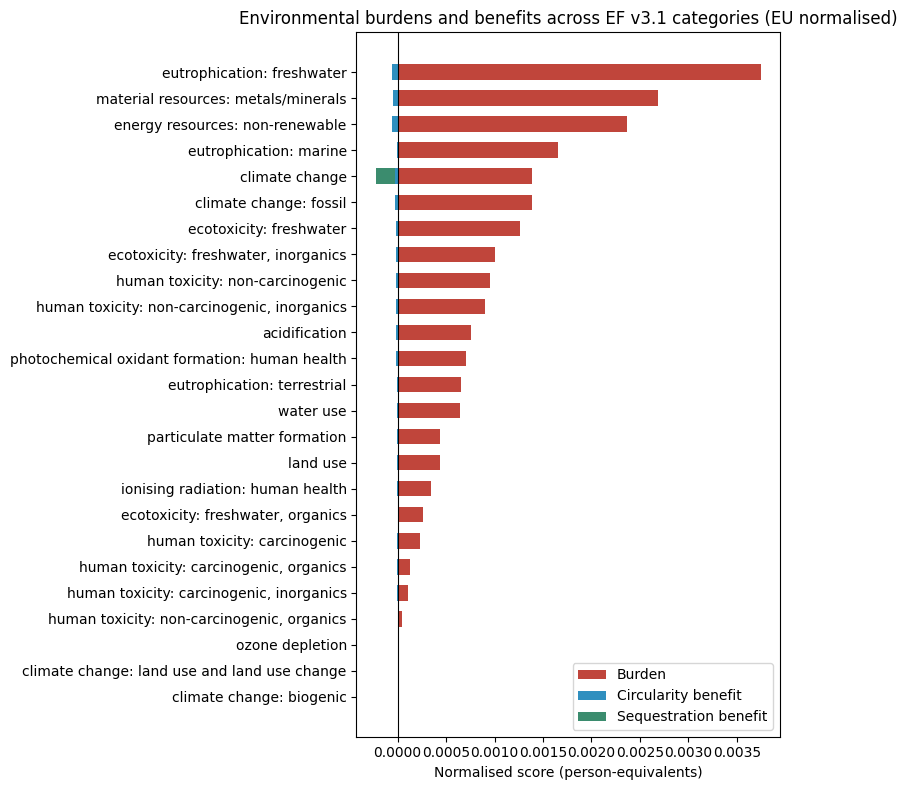

In [178]:
normalised_burdens = (total_burdens / pd.Series(EF_NORMALISATION)).dropna()
normalised_circularity = (total_circularity_benefits / pd.Series(EF_NORMALISATION)).dropna()
normalised_sequestration = (total_sequestration_benefits / pd.Series(EF_NORMALISATION)).dropna()

categories = normalised_burdens.sort_values().index  # order rows by burden magnitude
burden_vals = normalised_burdens.reindex(categories)
circ_vals = normalised_circularity.reindex(categories).fillna(0.0)
seq_vals = normalised_sequestration.reindex(categories).fillna(0.0)  # nonzero only for 'climate change'

y = range(len(categories))
bar_height = 0.6

fig, ax = plt.subplots(figsize=(8, 8))

# Burden bar (extends right, positive)
ax.barh(list(y), burden_vals.values, height=bar_height, color="#C0453B", label="Burden")

# Benefit bars (extend left, negative), stacked at the same row: circularity first,
# sequestration continues further left from where circularity ends.
ax.barh(list(y), circ_vals.values, height=bar_height, color="#2F8FBF", label="Circularity benefit")
ax.barh(list(y), seq_vals.values, height=bar_height,
        left=circ_vals.values, color="#3B8C6E", label="Sequestration benefit")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(categories)
ax.set_xlabel("Normalised score (person-equivalents)")
ax.set_title("Environmental burdens and benefits across EF v3.1 categories (EU normalised)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Breakdown — burdens and benefits per material / process (GWP100)

Burdens broken down by material (production + repair combined) and by individual
process step (production and repair chains each broken into their own steps,
rather than one aggregate bar per chain). Benefits broken down by material.
All bars shown together, climate change category only.

In [179]:
# ── Per-step process burden breakdown ────────────────────────────────────────
def get_process_burdens_by_step(chain, df_steps, label_suffix, category="climate change"):
    breakdown = {}
    for step, row in zip(chain, df_steps.itertuples()):
        machine_unit = get_unit_burden("machine wear", material_source=step.machine_source)[category]
        electricity_unit = get_unit_burden("energy use", location=step.electricity_location)[category]
        step_burden = row.machine_wear_kg * machine_unit + row.energy_use_kwh * electricity_unit
        breakdown[f"{step.step_name} ({label_suffix})"] = step_burden
    return breakdown

process_burden_breakdown = get_process_burdens_by_step(production_chain, df_production_steps, "production")
for name, val in get_process_burdens_by_step(repair_chain, df_repair_steps, "repair").items():
    process_burden_breakdown[name] = val * number_of_repair_events

# ── Per-item burden breakdown ──────────────────────────────────────────────
def get_material_burdens_by_item(bom, total_input_kg, category="climate change"):
    burdens = {}
    for item in bom:
        kg = total_input_kg * item.percentage / 100
        unit_burden = get_material_unit_burden(item.material_name, item.material_source)
        burdens[item.material_name] = burdens.get(item.material_name, 0.0) + unit_burden[category] * kg
    return burdens

def get_sequestration_credit_by_item(bom, total_kg, storage_yr):
    credits = {}
    for item in bom:
        if not is_growth_eligible(item.material_source):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, rotation_yr = get_benefit_params(item.material_name)
        credits[item.material_name] = credits.get(item.material_name, 0.0) + carbon_content * kg * MOLAR_RATIO * lookup_gwpbio(rotation_yr, storage_yr)
    return credits

def get_delayed_emissions_credit_by_item(bom, total_kg, storage_yr):
    credits = {}
    for item in bom:
        if is_growth_eligible(item.material_source):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, _ = get_benefit_params(item.material_name)
        credits[item.material_name] = credits.get(item.material_name, 0.0) + carbon_content * kg * MOLAR_RATIO * (dynamic_cf(storage_yr) - 1)
    return credits

material_burden_breakdown = get_material_burdens_by_item(production_bom, total_material_input_kg)
for name, val in get_material_burdens_by_item(repair_bom, repair_material_input_kg).items():
    material_burden_breakdown[name] = material_burden_breakdown.get(name, 0.0) + val * number_of_repair_events

# ── Per-item benefit breakdown ──────────────────────────────────────────────
material_benefit_breakdown = {}
for fn in (get_sequestration_credit_by_item, get_delayed_emissions_credit_by_item):
    for name, val in fn(production_bom, total_material_input_kg, production_storage_yr).items():
        material_benefit_breakdown[name] = material_benefit_breakdown.get(name, 0.0) + val
    for storage_yr in repair_storage_yr:
        for name, val in fn(repair_bom, repair_material_input_kg, storage_yr).items():
            material_benefit_breakdown[name] = material_benefit_breakdown.get(name, 0.0) + val

In [180]:
# ── Per-route EoL burden/benefit breakdown ─────────────────────────────────
eol_burden_breakdown = {
    "Compost (EoL)":        compost_burden["climate change"],
    "Recycle open (EoL)":   recycle_open_burden["climate change"],
    "Recycle closed (EoL)": recycle_closed_burden["climate change"],
    "Incinerate (EoL)":     incinerate_burden["climate change"],
    "Landfill (EoL)":       landfill_burden["climate change"],
}
eol_benefit_breakdown = {
    "Compost credit (EoL)":      compost_credit["climate change"],
    "Recycle open credit (EoL)": recycle_open_credit["climate change"],
    "Incinerate credit (EoL)":   incinerate_credit["climate change"],
}

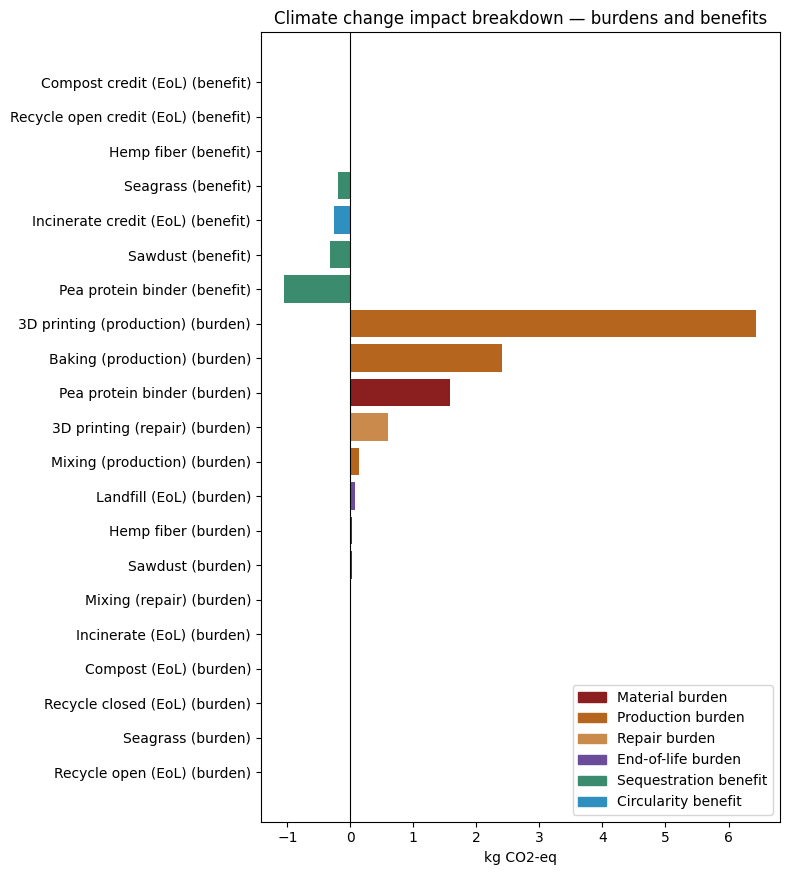

In [181]:
BURDEN_COLORS = {
    "material":   "#8B1E1E",  # deep red
    "production": "#B5651D",  # rust brown
    "repair":     "#C98A4B",  # tan/terracotta
    "eol":        "#6B4C9A",  # purple — end-of-life treatment
}
BENEFIT_COLORS = {
    "sequestration": "#3B8C6E",  # green
    "circularity":   "#2F8FBF",  # blue — EoL circularity credit
}

def classify_burden(name):
    if "(production)" in name:
        return "production"
    if "(repair)" in name:
        return "repair"
    if "(EoL)" in name:
        return "eol"
    return "material"

def classify_benefit(name):
    return "circularity" if "(EoL)" in name else "sequestration"

burden_items = {**material_burden_breakdown, **process_burden_breakdown, **eol_burden_breakdown}
benefit_items = {**material_benefit_breakdown, **eol_benefit_breakdown}

burden_series = pd.Series(burden_items).sort_values()
benefit_series = pd.Series(benefit_items).sort_values()

all_labels = [f"{name} (burden)" for name in burden_series.index] + [f"{name} (benefit)" for name in benefit_series.index]
all_values = list(burden_series.values) + list(benefit_series.values)
all_colors = (
    [BURDEN_COLORS[classify_burden(name)] for name in burden_series.index]
    + [BENEFIT_COLORS[classify_benefit(name)] for name in benefit_series.index]
)

fig, ax = plt.subplots(figsize=(8, 0.35 * len(all_labels) + 1.5))
ax.barh(all_labels, all_values, color=all_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("kg CO2-eq")
ax.set_title("Climate change impact breakdown — burdens and benefits")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=BURDEN_COLORS["material"],   label="Material burden"),
    Patch(color=BURDEN_COLORS["production"], label="Production burden"),
    Patch(color=BURDEN_COLORS["repair"],     label="Repair burden"),
    Patch(color=BURDEN_COLORS["eol"],        label="End-of-life burden"),
    Patch(color=BENEFIT_COLORS["sequestration"], label="Sequestration benefit"),
    Patch(color=BENEFIT_COLORS["circularity"],   label="Circularity benefit"),
], loc="lower right")

plt.tight_layout()
plt.show()